In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── MOCK DATA (PostgreSQL set hone tak)
np.random.seed(42)
comp = pd.DataFrame({
    'company_id': range(1, 101),
    'company_name': [f"Company_{i}" for i in range(1, 101)],
    'sector': np.random.choice(['IT','Banking','FMCG','Pharma','Auto','Energy'], 100),
    'roe_percentage': np.random.uniform(5, 40, 100)
})
pl = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'sales': np.random.uniform(500, 50000, 1000),
    'net_profit': np.random.uniform(50, 8000, 1000),
    'opm_pct': np.random.uniform(5, 35, 1000),
    'dividend_payout_pct': np.random.uniform(0, 60, 1000),
    'operating_profit': np.random.uniform(100, 10000, 1000),
    'interest': np.random.uniform(10, 500, 1000),
    'expenses': np.random.uniform(200, 40000, 1000),
})
bs = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'debt_to_equity': np.random.uniform(0, 3, 1000),
    'borrowings': np.random.uniform(0, 20000, 1000),
    'equity_capital': np.random.uniform(100, 5000, 1000),
    'reserves': np.random.uniform(500, 30000, 1000),
    'total_assets': np.random.uniform(1000, 80000, 1000),
})
cf = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'operating_activity': np.random.uniform(-500, 12000, 1000),
    'investing_activity': np.random.uniform(-8000, 1000, 1000),
    'free_cash_flow': np.random.uniform(-2000, 10000, 1000),
})
yr = pd.DataFrame({
    'year_id': range(2014, 2024),
    'year_label': [str(y) for y in range(2014, 2024)],
})
ana = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 3),
    'metric': np.tile(['compounded_sales_growth'], 300),
    'period_label': np.tile(['3Y', '5Y', '10Y'], 100),
    'value_pct': np.random.uniform(-5, 30, 300),
})

# Latest year per company
latest_year = pl.groupby('company_id')['year_id'].max().reset_index()
pl_latest = pl.merge(latest_year, on=['company_id','year_id'])
pl_latest = pl_latest.merge(comp[['company_id','company_name','sector']], on='company_id')
bs_latest = bs.merge(bs.groupby('company_id')['year_id'].max().reset_index(), on=['company_id','year_id'])
bs_latest = bs_latest.merge(comp[['company_id','company_name','sector']], on='company_id')

print("✅ Ready — 100 companies, 10 years each")

✅ Ready — 100 companies, 10 years each


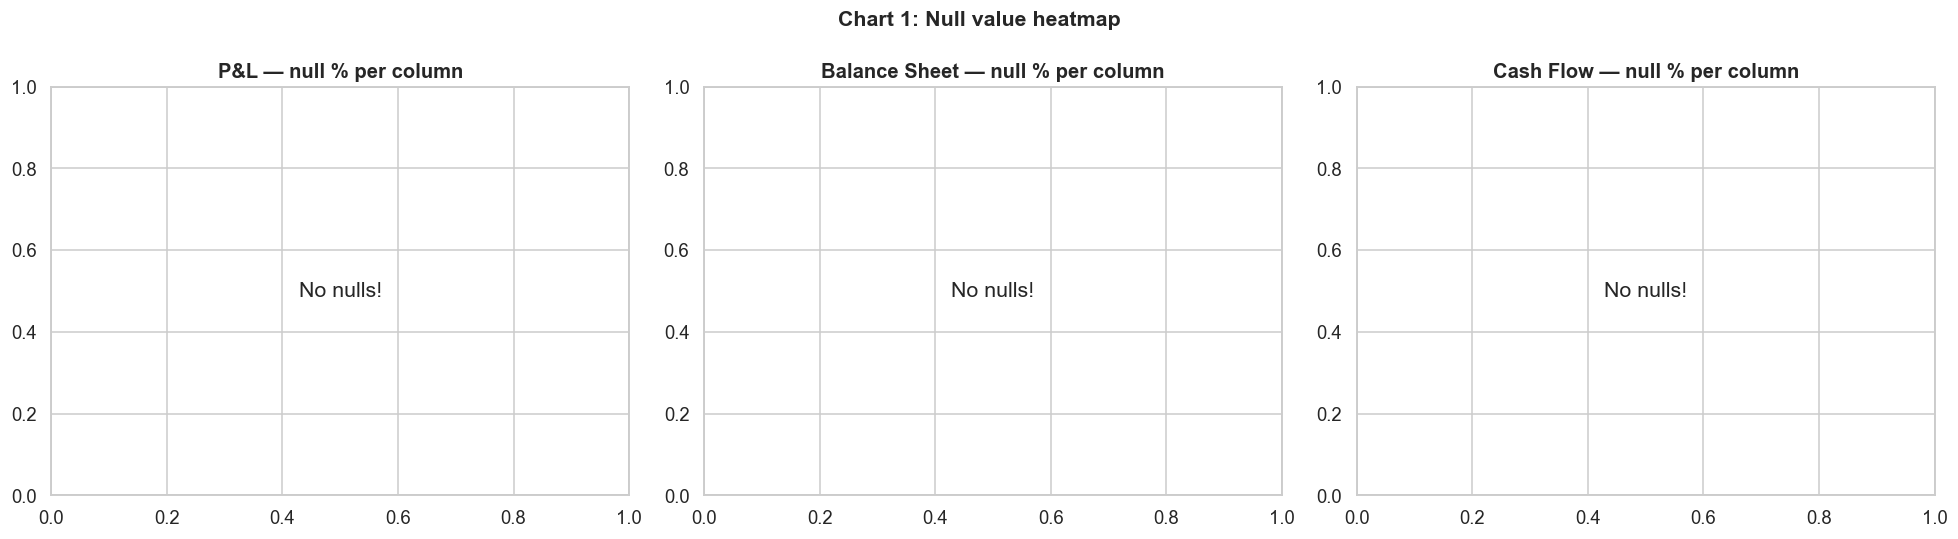

In [35]:
# Chart 1 — Null value heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [('P&L', pl), ('Balance Sheet', bs), ('Cash Flow', cf)]):
    null_pct = df.isnull().mean().sort_values(ascending=False) * 100
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, 'No nulls!', ha='center', va='center', transform=ax.transAxes, fontsize=14)
    else:
        sns.barplot(x=null_pct.values, y=null_pct.index, ax=ax, color='#E07070')
    ax.set_title(f'{name} — null % per column', fontweight='bold')

plt.suptitle('Chart 1: Null value heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

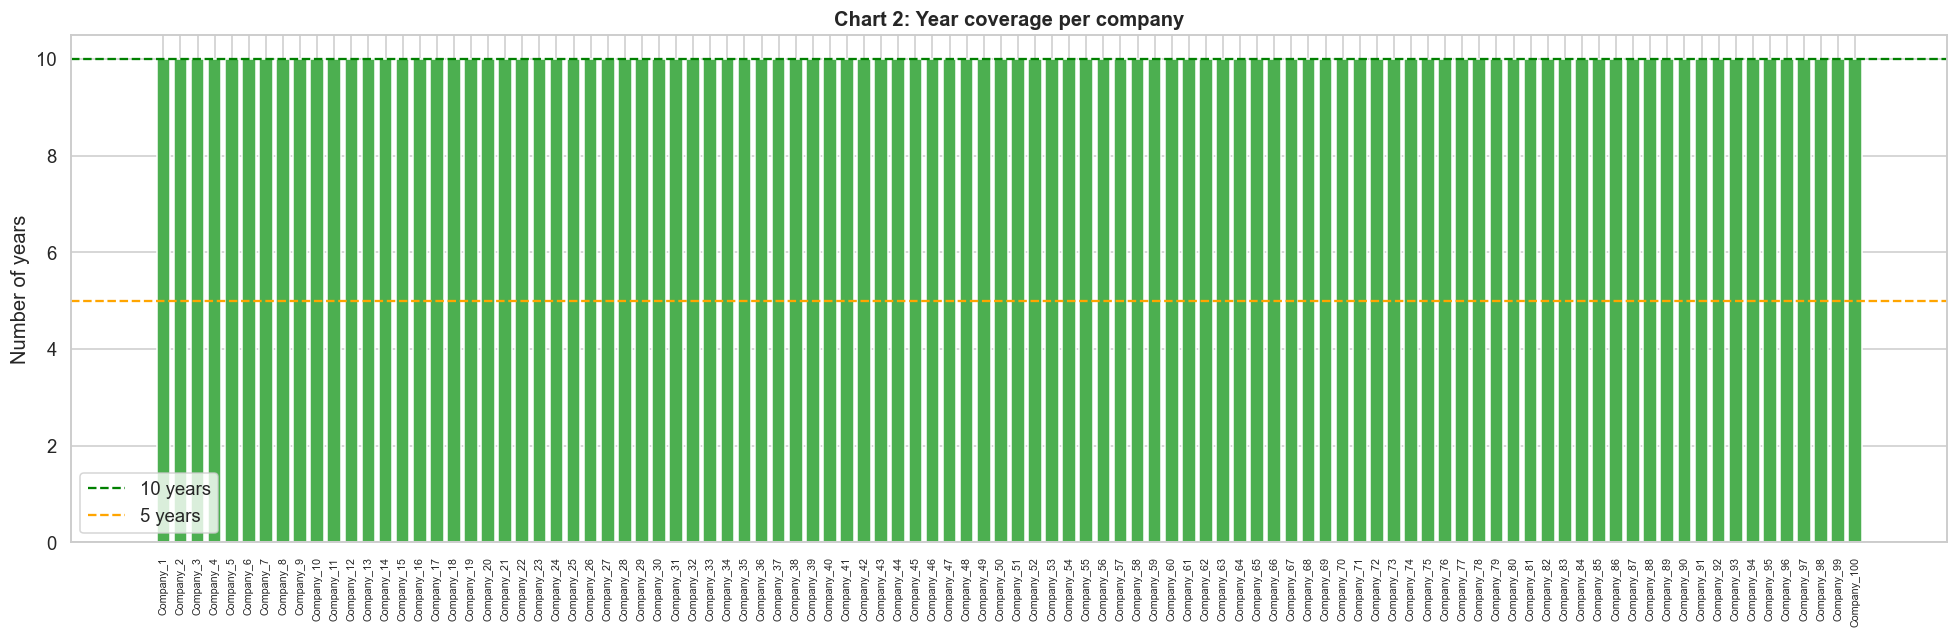

In [36]:
# Chart 2 — Year coverage per company
coverage = pl.groupby('company_id')['year_id'].count().reset_index()
coverage.columns = ['company_id', 'years_count']
coverage = coverage.merge(comp[['company_id', 'company_name', 'sector']], on='company_id')
coverage = coverage.sort_values('years_count', ascending=False)

fig, ax = plt.subplots(figsize=(18, 6))
colors = ['#4CAF50' if y >= 10 else '#FF9800' if y >= 5 else '#F44336' for y in coverage['years_count']]
ax.bar(coverage['company_name'], coverage['years_count'], color=colors, edgecolor='white')
ax.axhline(10, color='green', lw=1.5, linestyle='--', label='10 years')
ax.axhline(5, color='orange', lw=1.5, linestyle='--', label='5 years')
ax.set_xticklabels(coverage['company_name'], rotation=90, fontsize=7)
ax.set_ylabel('Number of years')
ax.set_title('Chart 2: Year coverage per company', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

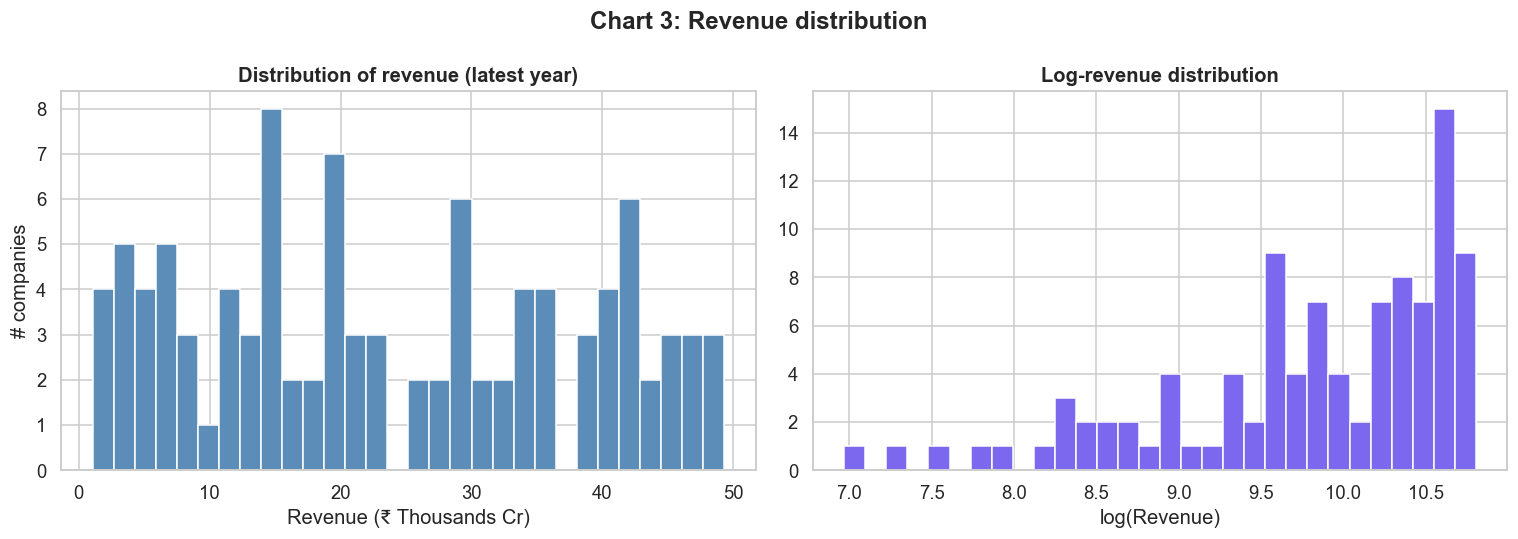

In [37]:
# Chart 3 — Revenue histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pl_latest['sales'].dropna() / 1e3, bins=30, color='#5B8DB8', edgecolor='white')
axes[0].set_xlabel('Revenue (₹ Thousands Cr)')
axes[0].set_ylabel('# companies')
axes[0].set_title('Distribution of revenue (latest year)', fontweight='bold')

axes[1].hist(np.log1p(pl_latest['sales'].dropna()), bins=30, color='#7B68EE', edgecolor='white')
axes[1].set_xlabel('log(Revenue)')
axes[1].set_title('Log-revenue distribution', fontweight='bold')

plt.suptitle('Chart 3: Revenue distribution', fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Chart 4 — Revenue box plot by sector
fig = px.box(
    pl_latest.dropna(subset=['sales', 'sector']),
    x='sector', y='sales',
    color='sector',
    points='outliers',
    title='Chart 4: Revenue box plot by sector',
    labels={'sales': 'Revenue (₹ Cr)', 'sector': 'Sector'},
    height=500
)
fig.update_layout(showlegend=False)
fig.write_html("chart4.html")
print("✅ Chart 4 saved — chart4.html kholo browser mein")

✅ Chart 4 saved — chart4.html kholo browser mein


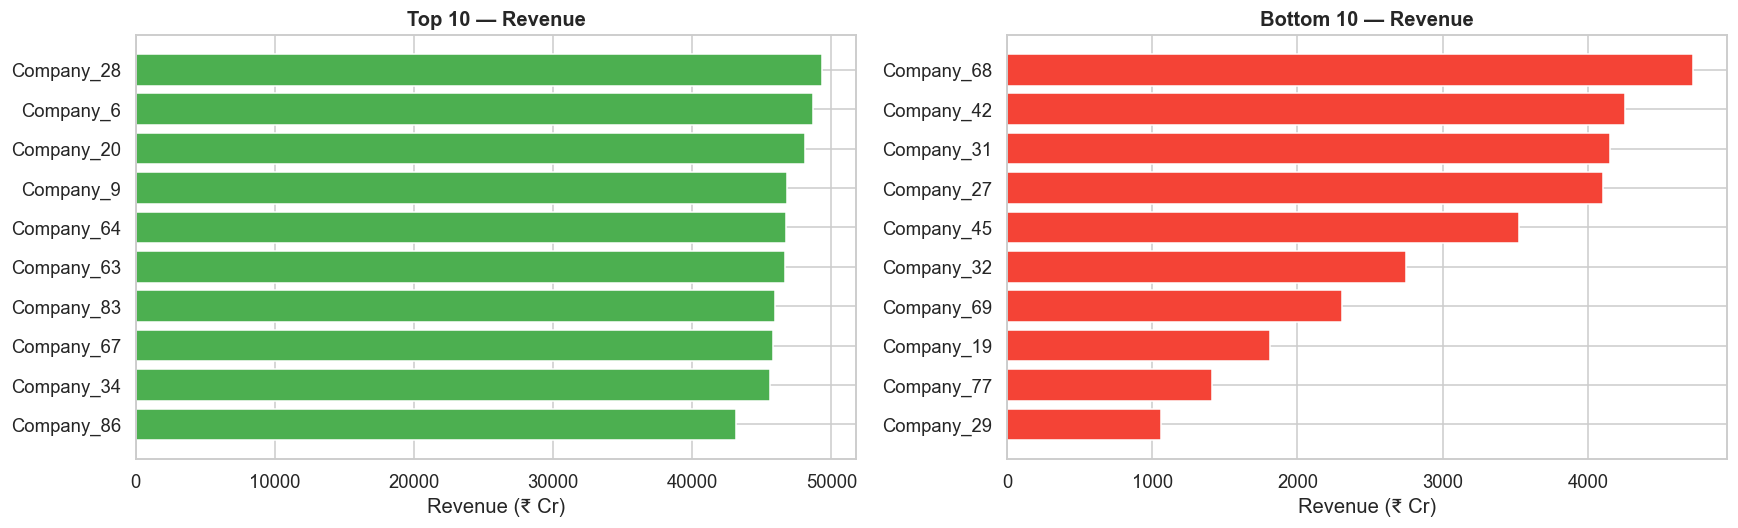

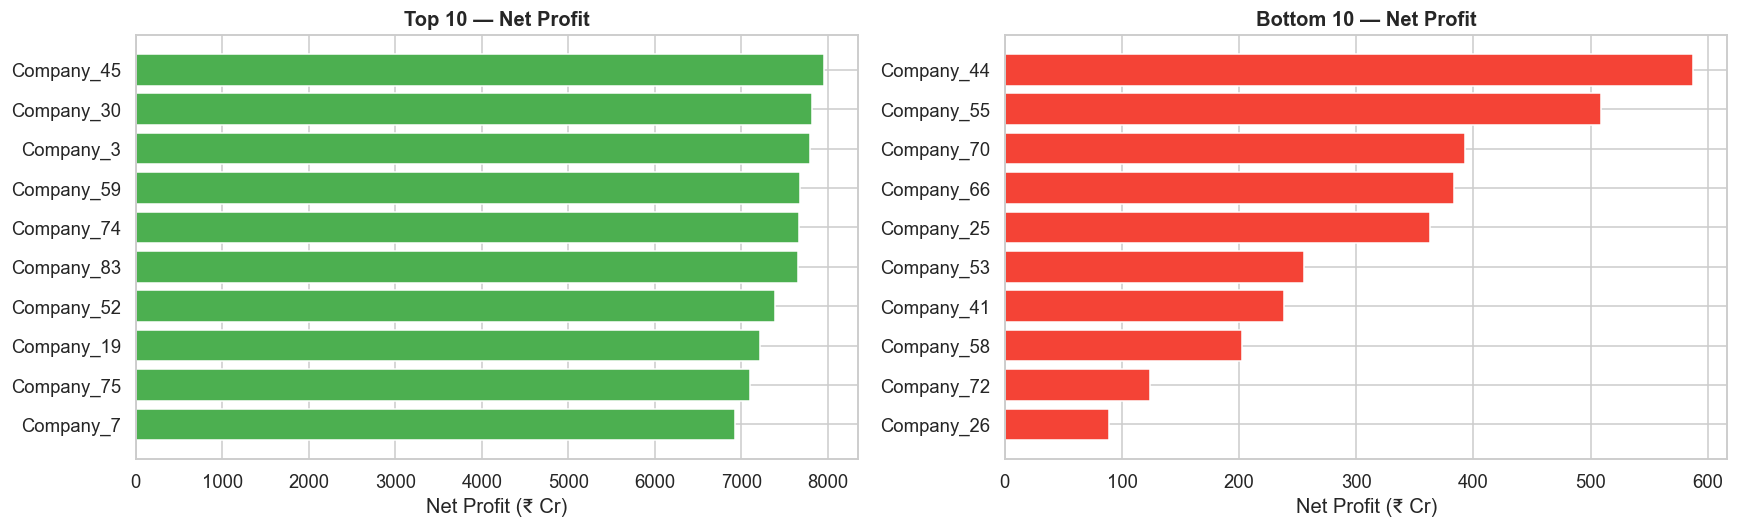

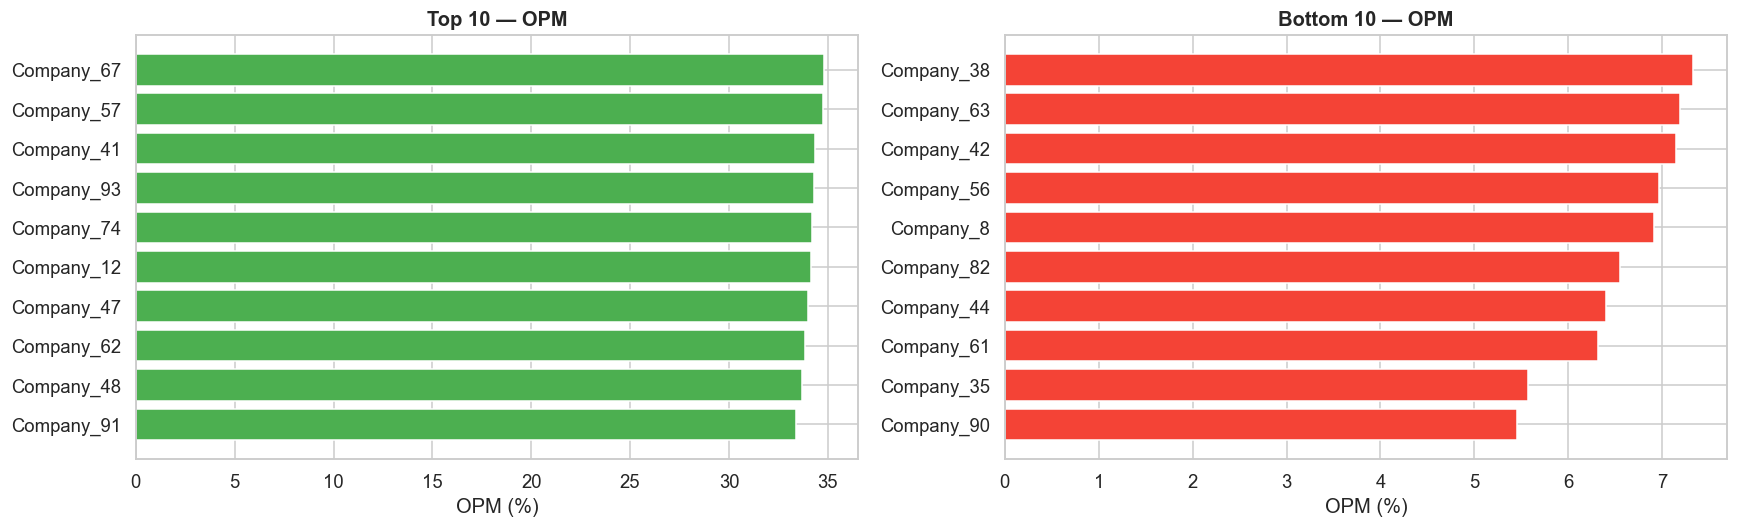

In [39]:
# Chart 5, 6, 7 — Top 10 / Bottom 10
def top_bottom_bar(df, col, label, color_top='#4CAF50', color_bot='#F44336', unit='₹ Cr'):
    top = df.nlargest(10, col)[['company_name', col]]
    bot = df.nsmallest(10, col)[['company_name', col]]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].barh(top['company_name'][::-1], top[col][::-1], color=color_top)
    axes[0].set_xlabel(f'{label} ({unit})')
    axes[0].set_title(f'Top 10 — {label}', fontweight='bold')
    
    axes[1].barh(bot['company_name'], bot[col], color=color_bot)
    axes[1].set_xlabel(f'{label} ({unit})')
    axes[1].set_title(f'Bottom 10 — {label}', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chart 5 — Revenue
top_bottom_bar(pl_latest, 'sales', 'Revenue')

# Chart 6 — Net Profit
top_bottom_bar(pl_latest, 'net_profit', 'Net Profit')

# Chart 7 — OPM%
top_bottom_bar(pl_latest, 'opm_pct', 'OPM', unit='%')

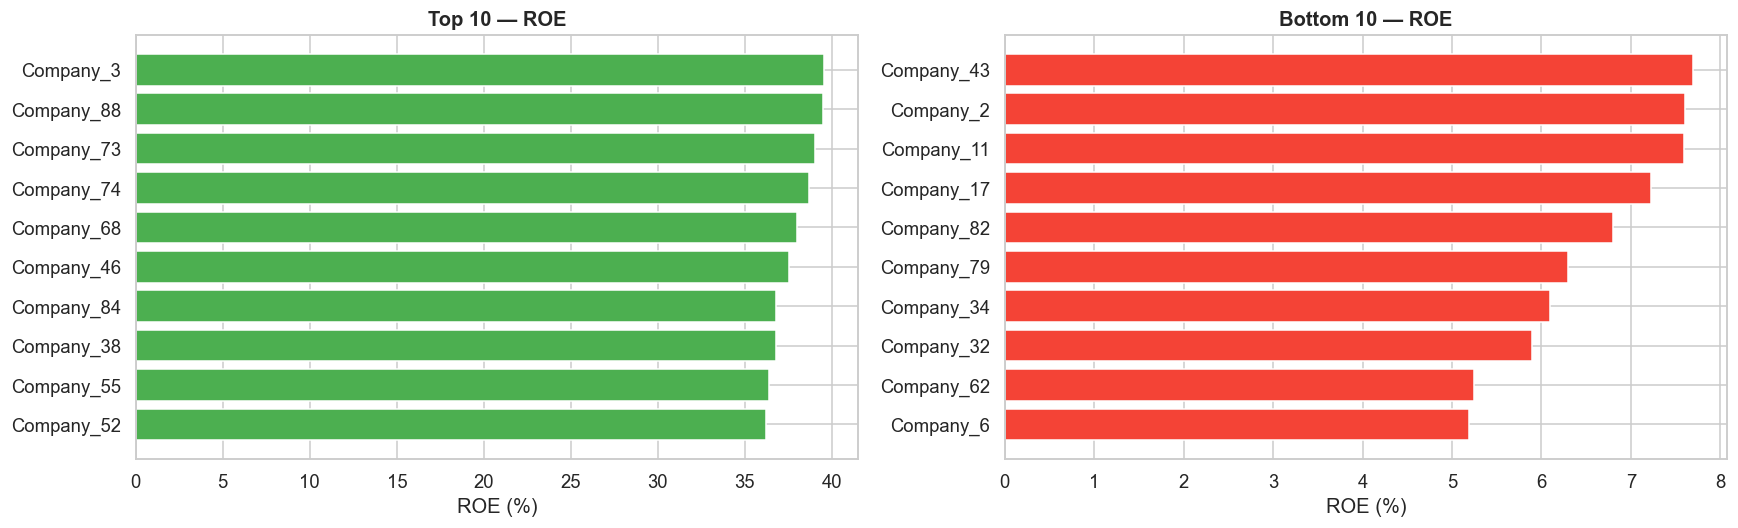

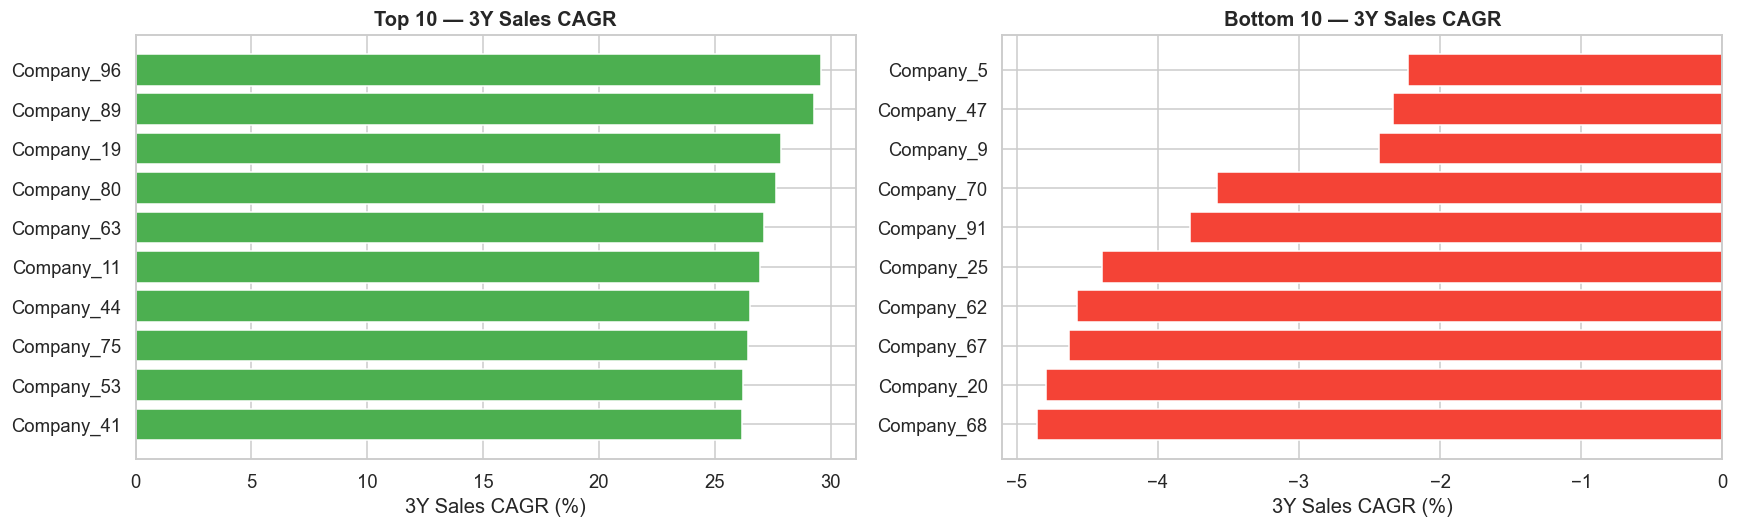

In [40]:
# Chart 8 — ROE
top_bottom_bar(comp.dropna(subset=['roe_percentage']), 'roe_percentage', 'ROE', unit='%')

# Chart 9 — 3Y Sales CAGR
cagr3 = ana[(ana['metric'] == 'compounded_sales_growth') & (ana['period_label'] == '3Y')]
cagr3 = cagr3.merge(comp[['company_id', 'company_name']], on='company_id', how='left')
cagr3 = cagr3.rename(columns={'value_pct': 'cagr_3y'})
top_bottom_bar(cagr3, 'cagr_3y', '3Y Sales CAGR', unit='%')

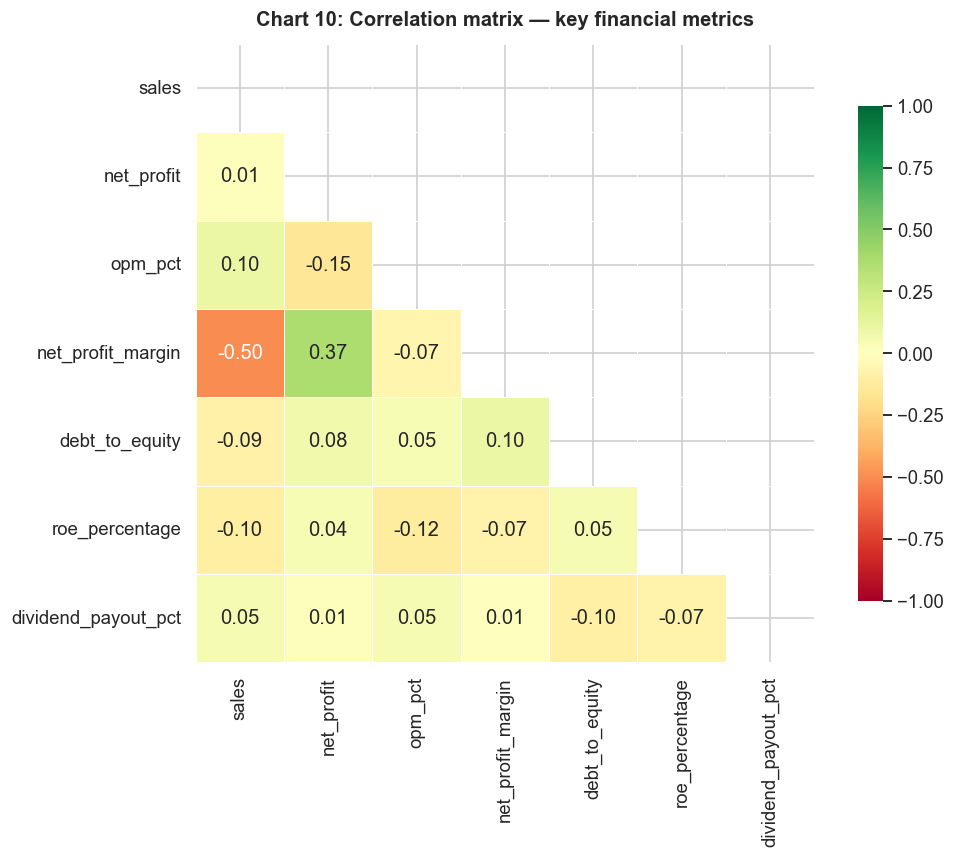

In [41]:
# Chart 10 — Correlation matrix
summary = pl_latest[['company_id', 'sales', 'net_profit', 'opm_pct', 'dividend_payout_pct']].copy()
summary = summary.merge(
    bs_latest[['company_id', 'debt_to_equity', 'total_assets', 'reserves']],
    on='company_id', how='left'
)
summary = summary.merge(comp[['company_id', 'roe_percentage']], on='company_id', how='left')
summary['net_profit_margin'] = summary['net_profit'] / summary['sales'] * 100

numeric_cols = ['sales', 'net_profit', 'opm_pct', 'net_profit_margin',
                'debt_to_equity', 'roe_percentage', 'dividend_payout_pct']
corr = summary[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Chart 10: Correlation matrix — key financial metrics', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [42]:
# Chart 11 — OPM% vs ROE
scatter_df = summary.dropna(subset=['opm_pct', 'roe_percentage'])
scatter_df = scatter_df.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')

fig = px.scatter(
    scatter_df, x='opm_pct', y='roe_percentage',
    color='sector', hover_name='company_name',
    trendline='ols',
    title='Chart 11: OPM% vs ROE',
    labels={'opm_pct': 'OPM %', 'roe_percentage': 'ROE %'},
    height=500
)
fig.write_html("chart11.html")
print("✅ chart11.html kholo browser mein")

✅ chart11.html kholo browser mein


In [43]:
# Chart 12 — D/E vs Net Profit Margin
fig = px.scatter(
    scatter_df.dropna(subset=['debt_to_equity', 'net_profit_margin']),
    x='debt_to_equity', y='net_profit_margin',
    color='sector', hover_name='company_name',
    trendline='ols',
    title='Chart 12: D/E vs Net Profit Margin',
    labels={'debt_to_equity': 'D/E Ratio', 'net_profit_margin': 'Net Profit Margin %'},
    height=500
)
fig.write_html("chart12.html")
print("✅ chart12.html kholo browser mein")

✅ chart12.html kholo browser mein


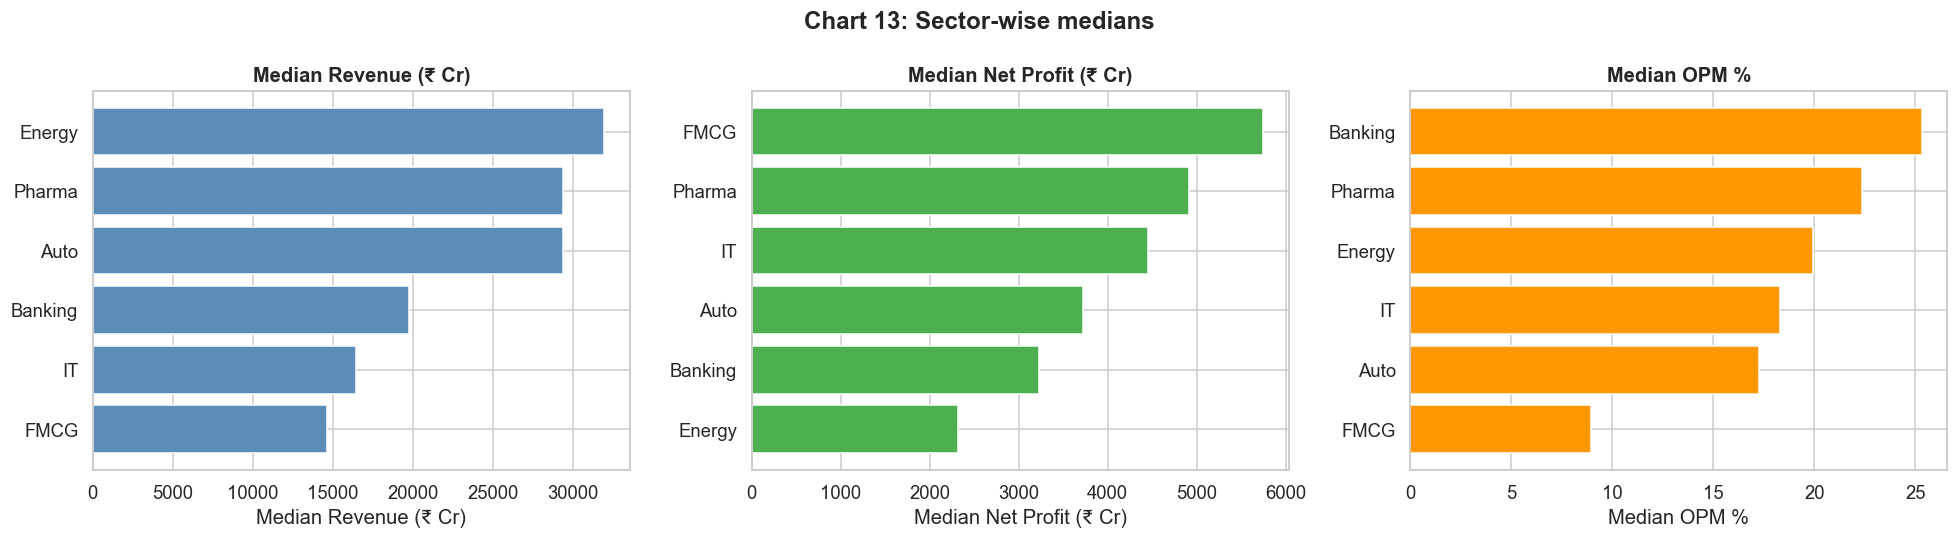

In [44]:
# Chart 13 — Sector-wise median revenue & net profit & OPM
sector_agg = (
    pl_latest
    .groupby('sector')[['sales', 'net_profit', 'opm_pct']]
    .median()
    .reset_index()
    .sort_values('sales', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label, color in zip(
    axes,
    ['sales', 'net_profit', 'opm_pct'],
    ['Median Revenue (₹ Cr)', 'Median Net Profit (₹ Cr)', 'Median OPM %'],
    ['#5B8DB8', '#4CAF50', '#FF9800']
):
    sorted_df = sector_agg.sort_values(col, ascending=True)
    ax.barh(sorted_df['sector'], sorted_df[col], color=color)
    ax.set_xlabel(label)
    ax.set_title(label, fontweight='bold')

plt.suptitle('Chart 13: Sector-wise medians', fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# Chart 14 — D/E by sector violin plot
fig = px.violin(
    bs_latest.dropna(subset=['debt_to_equity']),
    x='sector', y='debt_to_equity',
    color='sector', box=True, points='outliers',
    title='Chart 14: D/E ratio by sector',
    height=500
)
fig.update_yaxes(range=[0, 5])
fig.update_layout(showlegend=False)
fig.write_html("chart14.html")
print("✅ chart14.html kholo browser mein")

✅ chart14.html kholo browser mein


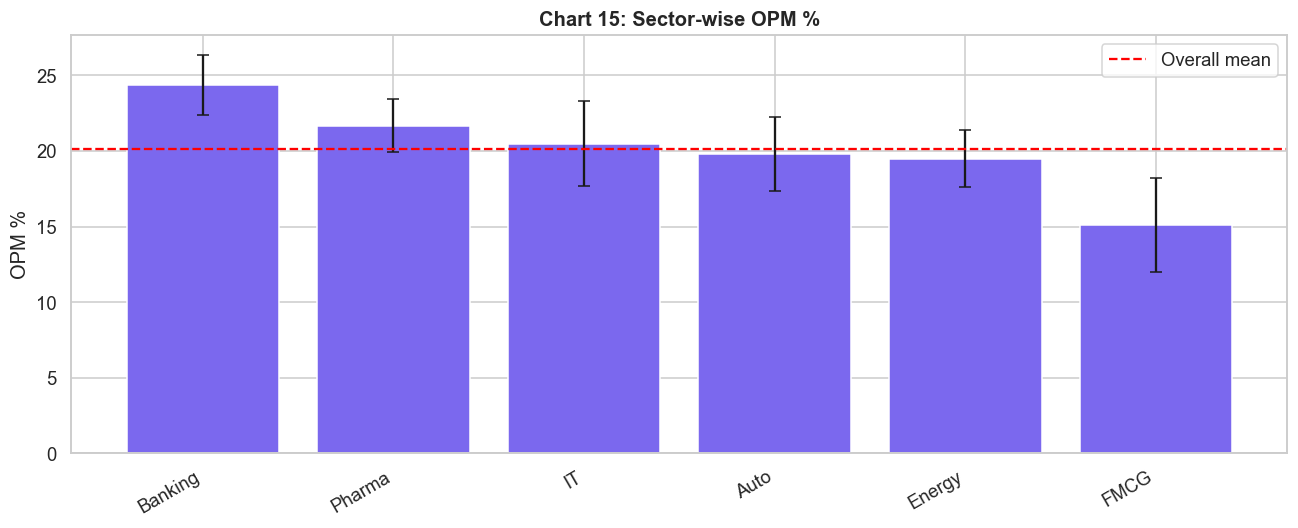

In [46]:
# Chart 15 — Sector OPM% mean
opm_sector = (
    pl_latest.dropna(subset=['opm_pct'])
    .groupby('sector')['opm_pct']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
opm_sector['se'] = opm_sector['std'] / np.sqrt(opm_sector['count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(opm_sector['sector'], opm_sector['mean'], color='#7B68EE',
       yerr=opm_sector['se'], capsize=4, edgecolor='white')
ax.axhline(opm_sector['mean'].mean(), color='red', lw=1.5,
           linestyle='--', label='Overall mean')
ax.set_ylabel('OPM %')
ax.set_xticklabels(opm_sector['sector'], rotation=30, ha='right')
ax.set_title('Chart 15: Sector-wise OPM %', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

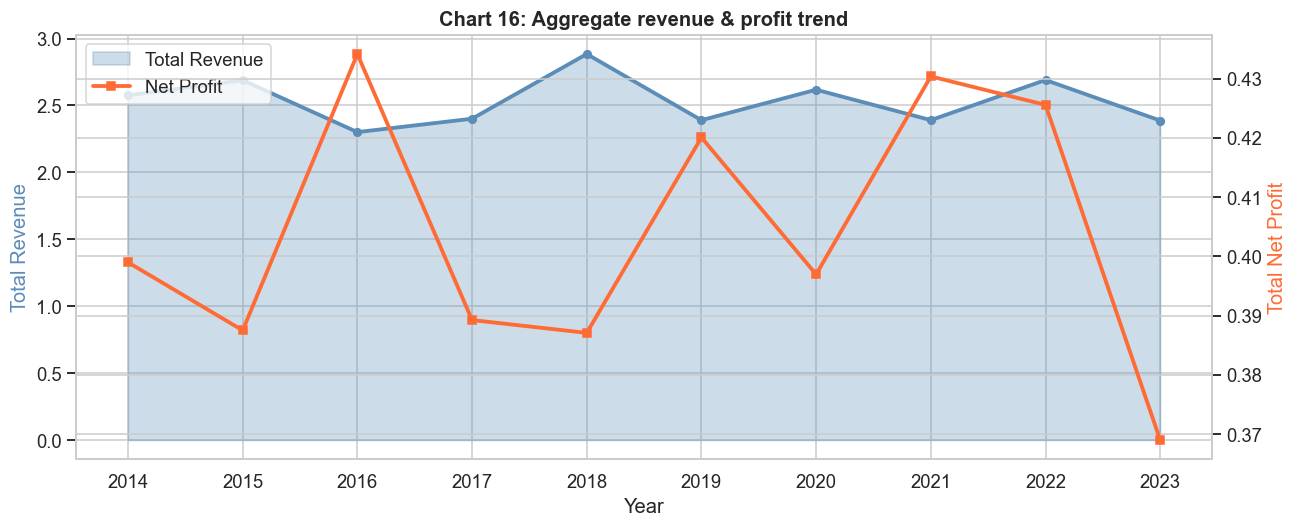

In [47]:
# Chart 16 — Aggregate revenue trend
pl_yr = pl.merge(yr[['year_id', 'year_label']], on='year_id', how='left')
agg_trend = pl_yr.groupby('year_label')[['sales', 'net_profit']].sum().reset_index()
agg_trend = agg_trend.sort_values('year_label')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(agg_trend['year_label'], agg_trend['sales'] / 1e6,
                 alpha=0.3, color='#5B8DB8', label='Total Revenue')
ax1.plot(agg_trend['year_label'], agg_trend['sales'] / 1e6,
         color='#5B8DB8', lw=2.5, marker='o', markersize=5)
ax2.plot(agg_trend['year_label'], agg_trend['net_profit'] / 1e6,
         color='#FF6B35', lw=2.5, marker='s', markersize=5, label='Net Profit')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Revenue', color='#5B8DB8')
ax2.set_ylabel('Total Net Profit', color='#FF6B35')
ax1.set_title('Chart 16: Aggregate revenue & profit trend', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

In [48]:
# Chart 17 — Top 5 revenue trend
top5 = pl_latest.nlargest(5, 'sales')['company_id'].tolist()
pl_top5 = pl_yr[pl_yr['company_id'].isin(top5)].merge(
    comp[['company_id', 'company_name']], on='company_id', how='left'
)

fig = px.line(
    pl_top5.sort_values('year_label'),
    x='year_label', y='sales',
    color='company_name', markers=True,
    title='Chart 17: Revenue trend — top 5 companies',
    height=450
)
fig.write_html("chart17.html")
print("✅ chart17.html kholo browser mein")

✅ chart17.html kholo browser mein


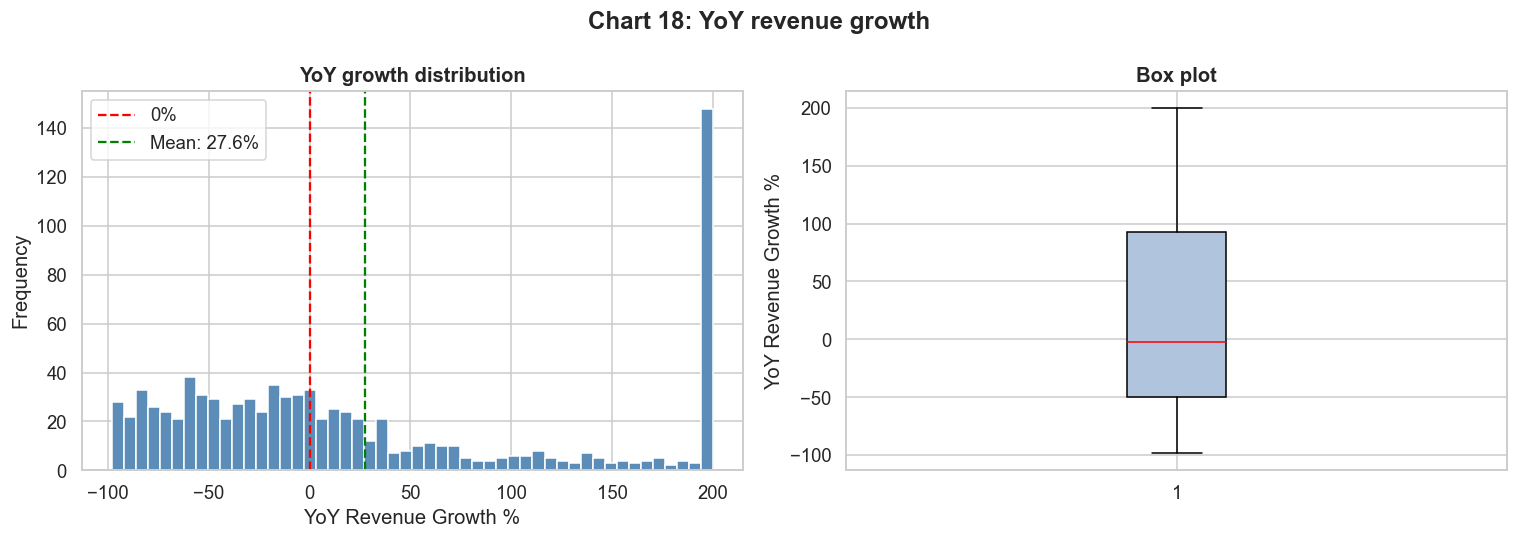

Mean YoY growth  : 27.6%
Median YoY growth: -2.6%
% positive years : 48.3%


In [49]:
# Chart 18 — YoY growth distribution
pl_sorted = pl_yr.sort_values(['company_id', 'year_label'])
pl_sorted['yoy_growth'] = pl_sorted.groupby('company_id')['sales'].pct_change() * 100
yoy_clean = pl_sorted['yoy_growth'].dropna().clip(-100, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(yoy_clean, bins=50, color='#5B8DB8', edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='0%')
axes[0].axvline(yoy_clean.mean(), color='green', lw=1.5,
                linestyle='--', label=f'Mean: {yoy_clean.mean():.1f}%')
axes[0].set_xlabel('YoY Revenue Growth %')
axes[0].set_ylabel('Frequency')
axes[0].set_title('YoY growth distribution', fontweight='bold')
axes[0].legend()

axes[1].boxplot(yoy_clean, patch_artist=True,
                boxprops=dict(facecolor='#B0C4DE'),
                medianprops=dict(color='red'))
axes[1].set_ylabel('YoY Revenue Growth %')
axes[1].set_title('Box plot', fontweight='bold')

plt.suptitle('Chart 18: YoY revenue growth', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean YoY growth  : {yoy_clean.mean():.1f}%")
print(f"Median YoY growth: {yoy_clean.median():.1f}%")
print(f"% positive years : {(yoy_clean > 0).mean()*100:.1f}%")

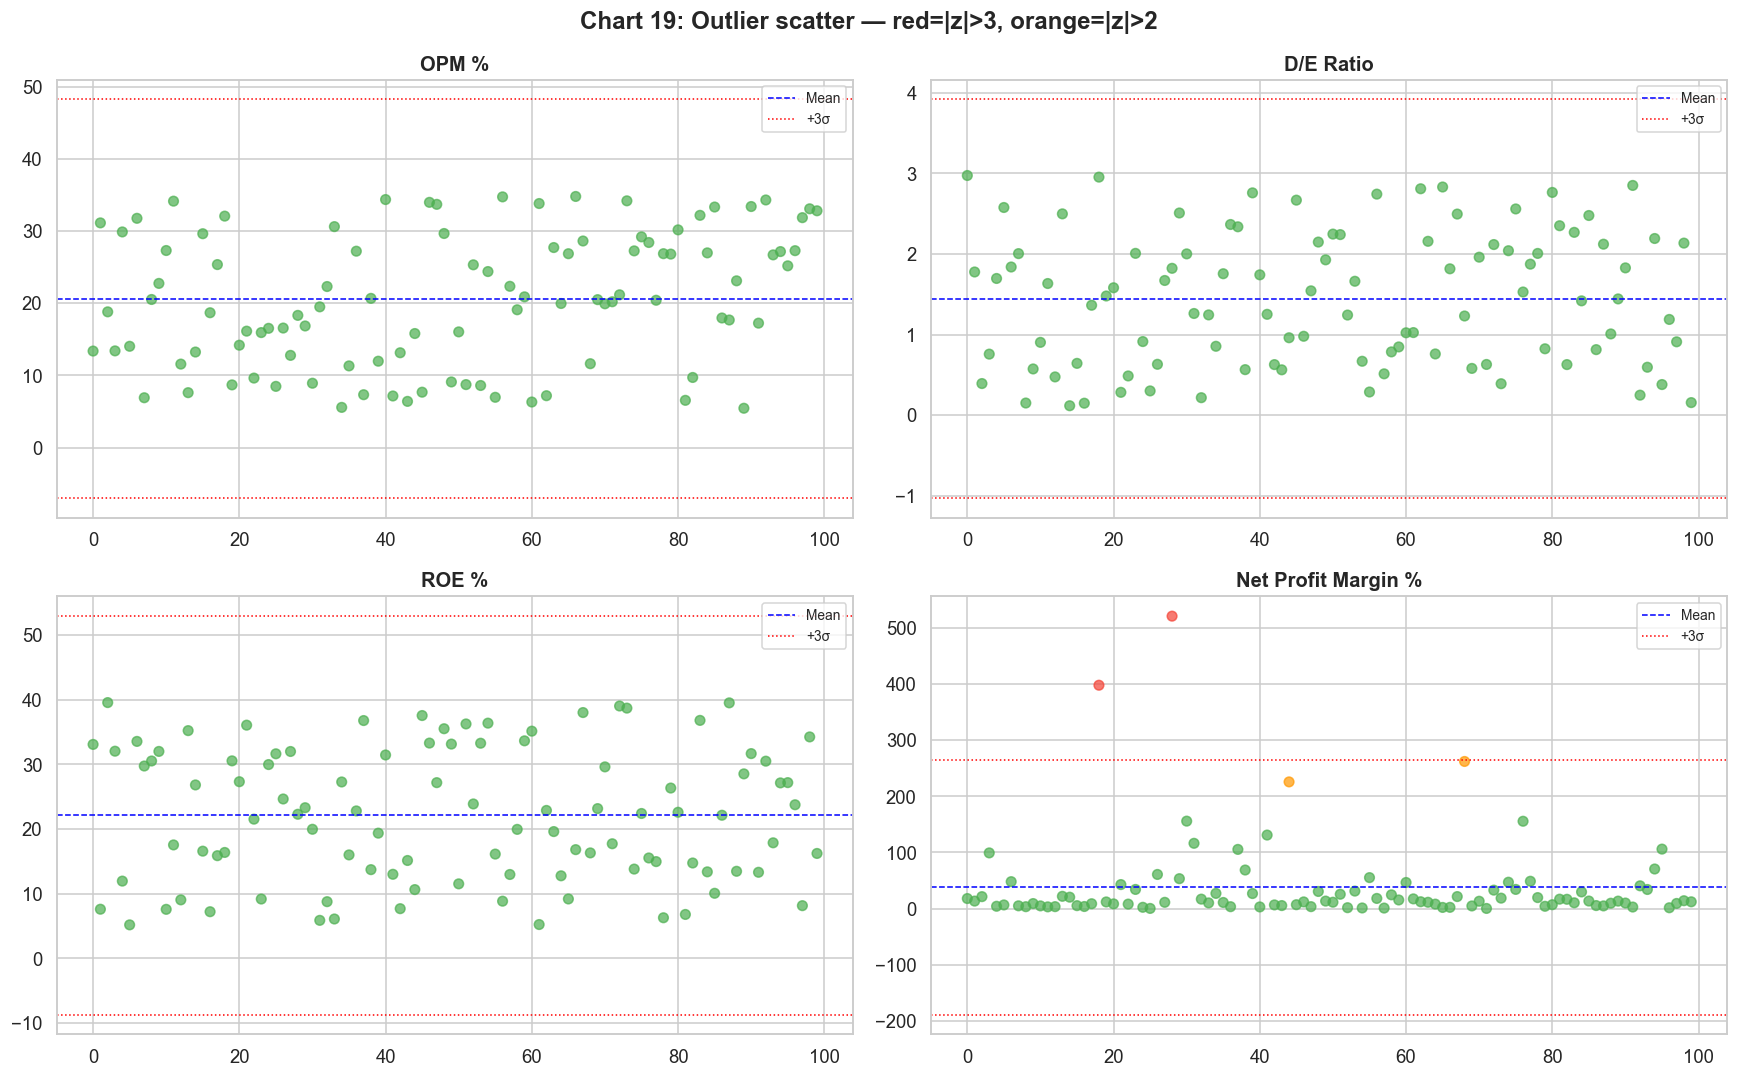


Top 10 outliers:
   company_name   sector  max_z  opm_pct  debt_to_equity  roe_percentage  net_profit_margin
28   Company_29       IT   6.42    18.32            1.82           22.28             520.88
18   Company_19  Banking   4.78    32.07            2.95           16.38             397.87
68   Company_69  Banking   2.98    11.63            1.23           16.31             262.11
44   Company_45     Auto   2.49    15.81            0.96           10.64             225.73
0     Company_1   Pharma   1.86    13.38            2.98           33.08              18.01
91   Company_92     Auto   1.71    17.24            2.85           13.32               2.88
2     Company_3     FMCG   1.71    18.81            0.39           39.54              21.38
87   Company_88   Energy   1.70    17.68            2.12           39.50               4.89
65   Company_66   Pharma   1.69    26.87            2.83            9.20               2.17
62   Company_63     FMCG   1.66     7.19            2.81      

In [50]:
# Chart 19 — Z-score outlier map
outlier_df = summary.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')

metrics = ['opm_pct', 'debt_to_equity', 'roe_percentage', 'net_profit_margin']
metric_labels = ['OPM %', 'D/E Ratio', 'ROE %', 'Net Profit Margin %']

for col in metrics:
    outlier_df[f'z_{col}'] = np.abs(stats.zscore(outlier_df[col].fillna(outlier_df[col].median())))

outlier_df['max_z'] = outlier_df[[f'z_{c}' for c in metrics]].max(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col, label in zip(axes.flat, metrics, metric_labels):
    data = outlier_df[col].dropna()
    z_scores = np.abs(stats.zscore(data))
    colors = ['#F44336' if z > 3 else '#FF9800' if z > 2 else '#4CAF50' for z in z_scores]
    ax.scatter(range(len(data)), data, c=colors, alpha=0.7, s=40)
    ax.axhline(data.mean(), color='blue', lw=1, linestyle='--', label='Mean')
    ax.axhline(data.mean() + 3*data.std(), color='red', lw=1, linestyle=':', label='+3σ')
    ax.axhline(data.mean() - 3*data.std(), color='red', lw=1, linestyle=':')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Chart 19: Outlier scatter — red=|z|>3, orange=|z|>2', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 outliers:")
print(outlier_df.nlargest(10, 'max_z')[['company_name', 'sector', 'max_z'] + metrics].round(2).to_string())

In [51]:
# Chart 20 — Parallel coordinates
para_df = outlier_df[['company_name', 'sector'] + metrics].dropna().copy()

for col in metrics:
    col_min, col_max = para_df[col].min(), para_df[col].max()
    para_df[col + '_n'] = (para_df[col] - col_min) / (col_max - col_min + 1e-9)

fig = px.parallel_coordinates(
    para_df,
    dimensions=[c + '_n' for c in metrics],
    labels={c + '_n': l for c, l in zip(metrics, metric_labels)},
    title='Chart 20: Financial fingerprint — all companies',
    height=500
)
fig.write_html("chart20.html")
print("✅ chart20.html kholo browser mein")

✅ chart20.html kholo browser mein


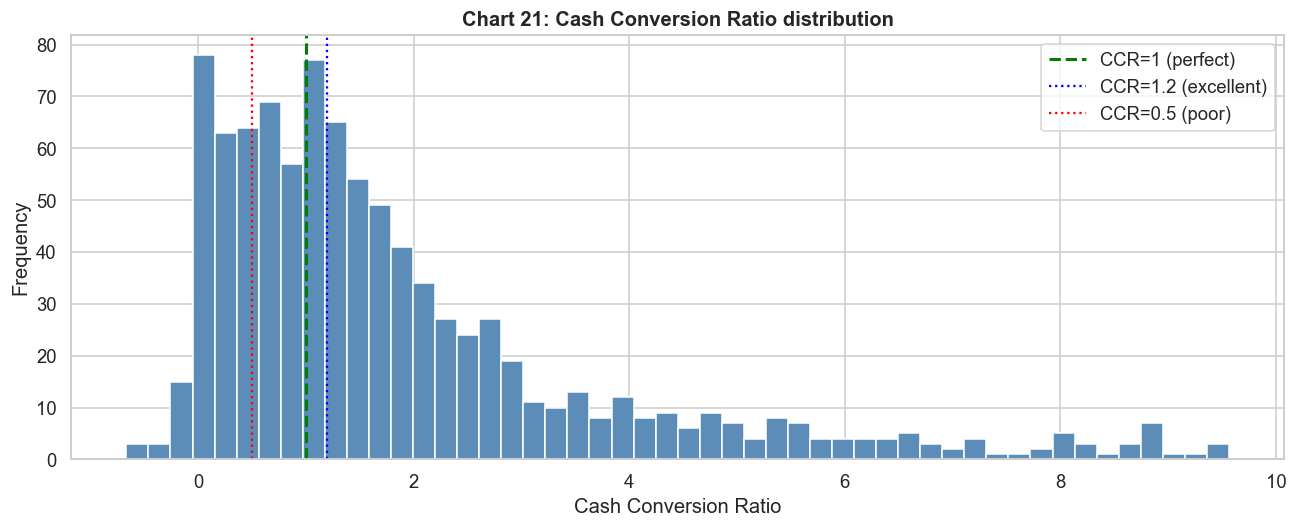

CCR > 1.2 (excellent): 502
CCR 0.8–1.2 (good)   : 131
CCR < 0.5 (poor)     : 203


In [52]:
# Chart 21 — Cash Conversion Ratio
cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
cf_pl_clean = cf_pl[cf_pl['ccr'].between(-5, 10)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(cf_pl_clean['ccr'], bins=50, color='#5B8DB8', edgecolor='white')
ax.axvline(1.0, color='green', lw=2, linestyle='--', label='CCR=1 (perfect)')
ax.axvline(1.2, color='blue', lw=1.5, linestyle=':', label='CCR=1.2 (excellent)')
ax.axvline(0.5, color='red', lw=1.5, linestyle=':', label='CCR=0.5 (poor)')
ax.set_xlabel('Cash Conversion Ratio')
ax.set_ylabel('Frequency')
ax.set_title('Chart 21: Cash Conversion Ratio distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"CCR > 1.2 (excellent): {(cf_pl_clean['ccr'] > 1.2).sum()}")
print(f"CCR 0.8–1.2 (good)   : {cf_pl_clean['ccr'].between(0.8, 1.2).sum()}")
print(f"CCR < 0.5 (poor)     : {(cf_pl_clean['ccr'] < 0.5).sum()}")

In [53]:
# Chart 22 — Net Profit vs Operating Cash Flow
cf_latest = cf.merge(
    cf.groupby('company_id')['year_id'].max().reset_index(),
    on=['company_id', 'year_id']
)
cf_latest = cf_latest.merge(pl_latest[['company_id', 'net_profit']], on='company_id', how='left')
cf_latest = cf_latest.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')

fig = px.scatter(
    cf_latest.dropna(subset=['net_profit', 'operating_activity']),
    x='net_profit', y='operating_activity',
    color='sector', hover_name='company_name',
    trendline='ols',
    title='Chart 22: Net Profit vs Operating Cash Flow',
    labels={'net_profit': 'Net Profit (₹ Cr)', 'operating_activity': 'OCF (₹ Cr)'},
    height=500
)
fig.write_html("chart22.html")
print("✅ chart22.html kholo browser mein")

✅ chart22.html kholo browser mein


In [54]:
# Chart 23 — Dividend payout by sector
div_df = pl.merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')
div_df = div_df[div_df['dividend_payout_pct'] > 0]

fig = px.box(
    div_df, x='sector', y='dividend_payout_pct',
    color='sector', points='outliers',
    title='Chart 23: Dividend payout % by sector',
    height=450
)
fig.update_layout(showlegend=False)
fig.write_html("chart23.html")
print("✅ chart23.html kholo browser mein")

✅ chart23.html kholo browser mein


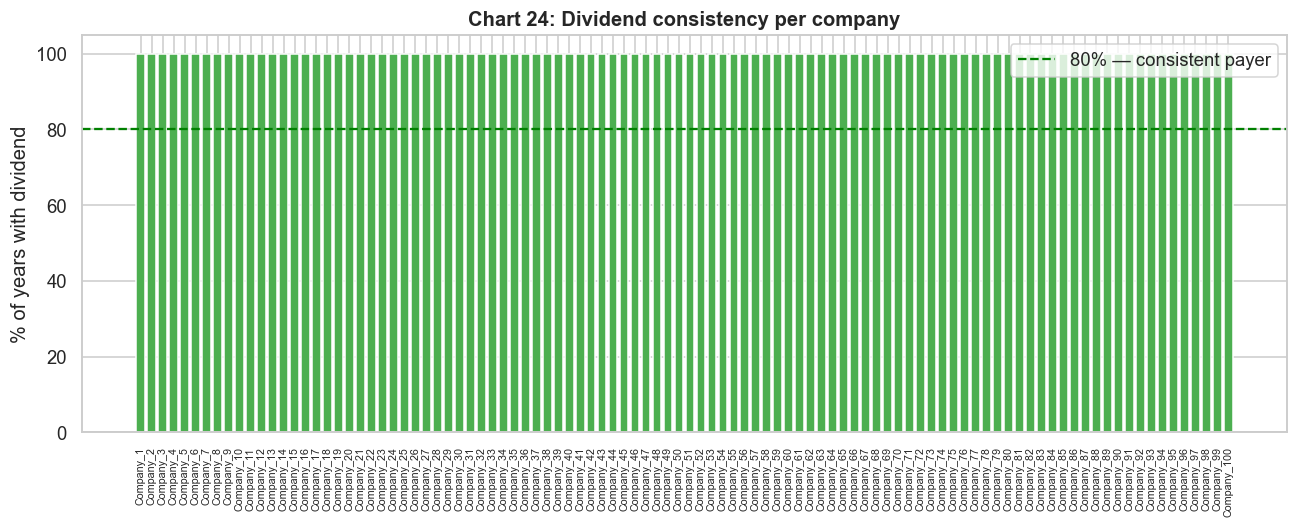

In [55]:
# Chart 24 — Dividend consistency per company
div_consistency = (
    pl[pl['dividend_payout_pct'] > 0]
    .groupby('company_id')['year_id'].count()
    .reset_index()
    .rename(columns={'year_id': 'div_years'})
    .merge(comp[['company_id', 'company_name', 'sector']], on='company_id', how='left')
    .merge(coverage[['company_id', 'years_count']], on='company_id', how='left')
)
div_consistency['div_pct'] = div_consistency['div_years'] / div_consistency['years_count'] * 100
div_consistency = div_consistency.sort_values('div_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4CAF50' if p >= 80 else '#FF9800' if p >= 50 else '#F44336'
          for p in div_consistency['div_pct']]
ax.bar(div_consistency['company_name'], div_consistency['div_pct'],
       color=colors, edgecolor='white')
ax.axhline(80, color='green', lw=1.5, linestyle='--', label='80% — consistent payer')
ax.set_xticklabels(div_consistency['company_name'], rotation=90, fontsize=7)
ax.set_ylabel('% of years with dividend')
ax.set_title('Chart 24: Dividend consistency per company', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Summary
print("="*60)
print("EDA SUMMARY")
print("="*60)
print(f"\n📊 Dataset: {comp.shape[0]} companies, {comp['sector'].nunique()} sectors")
print(f"   P&L records: {pl.shape[0]}")
print(f"   Years: {yr['year_label'].min()} → {yr['year_label'].max()}")
print(f"\n💰 Revenue (latest year):")
print(f"   Max   : ₹{pl_latest['sales'].max():>10,.0f} Cr — {pl_latest.loc[pl_latest['sales'].idxmax(), 'company_name']}")
print(f"   Min   : ₹{pl_latest['sales'].min():>10,.0f} Cr — {pl_latest.loc[pl_latest['sales'].idxmin(), 'company_name']}")
print(f"   Median: ₹{pl_latest['sales'].median():>10,.0f} Cr")
print(f"\n📈 Avg YoY growth : {yoy_clean.mean():.1f}%")
print(f"   % positive years: {(yoy_clean > 0).mean()*100:.1f}%")
print(f"\n✅ Notebook 1 complete! Ready for Notebook 2 — Health Scoring")

EDA SUMMARY

📊 Dataset: 100 companies, 6 sectors
   P&L records: 1000
   Years: 2014 → 2023

💰 Revenue (latest year):
   Max   : ₹    49,307 Cr — Company_28
   Min   : ₹     1,062 Cr — Company_29
   Median: ₹    21,364 Cr

📈 Avg YoY growth : 27.6%
   % positive years: 48.3%

✅ Notebook 1 complete! Ready for Notebook 2 — Health Scoring


In [57]:
# DB Connection Test
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv('../.env')

DB = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)

engine = create_engine(DB)

try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT table_name FROM information_schema.tables WHERE table_schema='public'"))
        tables = [row[0] for row in result]
        print("✅ DB Connected!")
        print(f"Tables found: {tables}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ DB Connected!
Tables found: ['dim_company', 'fact_profit_loss', 'dim_year', 'fact_balance_sheet', 'fact_cash_flow', 'fact_analysis', 'fact_ml_scores', 'fact_pros_cons', 'fact_trend_labels']
